In [1]:
!pip install bitarray
from __future__ import annotations

import argparse
import hashlib
import string
from collections.abc import Callable, Iterable
from pathlib import Path
import json
import matplotlib.pyplot as plt
from hashlib import blake2b, sha256, sha3_256
from bitarray import bitarray

In [3]:
from google.colab import files

uploaded = files.upload()

Saving words.txt to words (3).txt


In [4]:
with open('words.txt') as f:
  words = [line.strip().lower() for line in f if line.strip()]

# Part 1: Algorithmic Mechanics & Data Reconstruction Leakage

In [5]:
# A hash function used by this Bloom filter:
#   input:  a string and the size of the bit vector
#   output: an integer index between 0 and size - 1
HashFunction = Callable[[str, int], int]

def _digest_index(value: str, size: int, algorithm: str) -> int:
    """
    Convert a word into a valid Bloom-filter index.

    Steps:
    1. Encode the Python string as UTF-8 bytes.
    2. Hash those bytes with the selected cryptographic hash algorithm.
    3. Convert the resulting bytes into one large integer.
    4. Use modulo to map the integer into the range of the bit vector.

    For example, if size is 10**7, the returned index will be between
    0 and 9,999,999.
    """
    digest = hashlib.new(
        algorithm,
        value.encode("utf-8")
    ).digest()

    hash_as_integer = int.from_bytes(
        digest,
        byteorder="big"
    )

    return hash_as_integer % size


def hash_1(value: str, size: int) -> int:
    """
    First Bloom-filter hash function: SHA-256.
    """
    return _digest_index(value, size, "sha256")


def hash_2(value: str, size: int) -> int:
    """
    Second Bloom-filter hash function: SHA-512.
    """
    return _digest_index(value, size, "sha512")


def hash_3(value: str, size: int) -> int:
    """
    Third Bloom-filter hash function: SHA-1.
    """
    return _digest_index(value, size, "sha1")


# use of three has functions
DEFAULT_HASH_FUNCTIONS: tuple[HashFunction, ...] = (
    hash_1,
    hash_2,
    hash_3,
)


class BloomFilter:
    """
    A memory-efficient Bloom filter.

    The filter contains a fixed-size vector of bits. Instead of storing
    each word directly, adding a word sets several positions in the bit
    vector to 1.

    During a membership query:

    - If at least one required bit is 0, the word is definitely absent.
    - If all required bits are 1, the word might be present.

    Therefore, Bloom filters can produce false positives but not false
    negatives, assuming that the same hash functions and normalization
    procedure are used for both insertion and querying.
    """

    def __init__(
        self,
        size: int,
        hash_functions: Iterable[HashFunction] = DEFAULT_HASH_FUNCTIONS,
    ) -> None:
        """
        Create a Bloom filter.

        Parameters
        ----------
        size:
            Number of bits in the Bloom filter.

        hash_functions:
            Hash functions that determine which bits are set or checked.
        """
        if size <= 0:
            raise ValueError("size must be positive")

        self.size = size
        self.hash_functions = tuple(hash_functions)

        if not self.hash_functions:
            raise ValueError("at least one hash function is required")

        # A byte contains eight bits. Therefore, a Bloom filter containing
        # 10**7 bits needs:
        #
        #     ceil(10**7 / 8) = 1,250,000 bytes
        #
        # This is approximately 1.25 MB.
        self._bits = bytearray((size + 7) // 8)

    def _indexes(self, value: str):
        """
        Generate every bit index associated with a value.

        One index is produced by each active hash function.
        """
        for hash_function in self.hash_functions:
            yield hash_function(value, self.size)

    def add(self, value: str) -> None:
        """
        Add a value to the Bloom filter.

        For every hash result, locate the corresponding bit and set it to 1.
        """
        for index in self._indexes(value):
            # index >> 3 is equivalent to index // 8 and identifies
            # which byte contains the desired bit.
            byte_index = index >> 3

            # index & 7 is equivalent to index % 8 and identifies
            # the bit's position inside that byte.
            bit_position = index & 7

            # Set the selected bit to 1 while leaving the other bits unchanged.
            self._bits[byte_index] |= 1 << bit_position

    def __contains__(self, value: str) -> bool:
        """
        Check whether a value might be in the Bloom filter.

        Returns
        -------
        bool
            False means the value is definitely absent.
            True means the value might be present.
        """
        for index in self._indexes(value):
            byte_index = index >> 3
            bit_position = index & 7

            # If one required bit is 0, the value was definitely not added.
            if not self._bits[byte_index] & (1 << bit_position):
                return False

        # All required bits are 1. The value might have been added,
        # but this could also be a false positive caused by collisions.
        return True


def suggest_corrections(
    typed_word: str,
    bloom_filter: BloomFilter
) -> list[str]:
    """
    Generate valid single-character substitutions for a typed word.

    A single-character substitution changes exactly one character while
    keeping the word length unchanged.

    For example, one possible mutation of "floeer" is "flower":

        floeer
           ^
        flower

    The function tries every lowercase letter at every position. Each
    candidate is then queried against the Bloom filter. Candidates that
    the Bloom filter reports as possible members are returned.

    Parameters
    ----------
    typed_word:
        The potentially misspelled word.

    bloom_filter:
        The Bloom filter containing the protected vocabulary.

    Returns
    -------
    list[str]
        Candidates accepted by the Bloom filter, in generation order.
        Some candidates may be false positives.
    """
    suggestions: list[str] = []

    # Examine each character position in the typed word.
    for index, original_character in enumerate(typed_word):

        # Try replacing that character with every lowercase English letter.
        for replacement in string.ascii_lowercase:

            # A substitution must actually change the character.
            # Otherwise, the candidate would be identical to typed_word.
            if replacement == original_character:
                continue

            # Construct a new string containing exactly one changed character.
            candidate = (
                typed_word[:index]
                + replacement
                + typed_word[index + 1:]
            )

            # A Bloom-filter True result means that the candidate might
            # be in the protected vocabulary.
            if candidate in bloom_filter:
                suggestions.append(candidate)

    return suggestions


# load_words is kept, but it won't be used by the modified main function.
def load_words(
    path: str | Path,
    bloom_filter: BloomFilter
) -> int:
    """
    Load words from a text file into the Bloom filter.

    The file should contain one word per line.

    Words are converted to lowercase before insertion. This normalization
    is important because the supplied words.txt contains "Flower" with an
    uppercase F, while the generated correction candidate is "flower".

    Returns
    -------
    int
        Number of nonempty lines inserted into the Bloom filter.
    """
    count = 0

    with Path(path).open(encoding="utf-8") as word_file:
        for line in word_file:
            # Remove whitespace and normalize the word to lowercase.
            word = line.strip().lower()

            # Ignore empty lines.
            if not word:
                continue

            bloom_filter.add(word)
            count += 1

    return count


def main() -> None:
    """
    Run the required experiment using one, two, and three hash functions.
    """
    # Default values, mimicking argparse defaults
    typed_word_to_correct = "floeer"
    bloom_filter_size = 10**7

    # Assume 'words' list is available globally, loaded from a previous cell
    global words

    # Run three separate experiments:
    #
    # 1. SHA-256 only
    # 2. SHA-256 and SHA-512
    # 3. SHA-256, SHA-512, and SHA-1
    for hash_count in range(1, 4):
        active_hashes = DEFAULT_HASH_FUNCTIONS[:hash_count]

        bloom_filter = BloomFilter(
            size=bloom_filter_size,
            hash_functions=active_hashes,
        )

        # Directly add words from the global 'words' list
        for word in words:
            bloom_filter.add(word)
        number_of_words = len(words)

        suggestions = suggest_corrections(
            typed_word_to_correct.lower(),
            bloom_filter,
        )

        print(
            f"{hash_count} hash function(s), "
            f"{number_of_words} words:"
        )
        print(suggestions)


if __name__ == "__main__":
    main()

1 hash function(s), 466550 words:
['bloeer', 'qloeer', 'fyoeer', 'flofer', 'floter', 'flower', 'floeqr', 'floees']
2 hash function(s), 466550 words:
['fyoeer', 'floter', 'flower']
3 hash function(s), 466550 words:
['floter', 'flower']


# Part 2: Empirical Evaluation & Plotting

In [6]:
from google.colab import files

uploaded = files.upload()

Saving typos (1).json to typos (1) (3).json


In [12]:
import string

def suggest_corrections(typed_word, bloom_filter):
    """
    Return valid one-character substitutions.

    If the original typed word is already valid,
    include it in the suggestion list.
    """

    typed_word = typed_word.lower()
    suggestions = []

    # Include the original word if it is already valid
    if typed_word in bloom_filter:
        suggestions.append(typed_word)

    # Generate one-character substitutions
    for index, original_character in enumerate(typed_word):

        for replacement in string.ascii_lowercase:

            # The original word was already checked above
            if replacement == original_character:
                continue

            candidate = (
                typed_word[:index]
                + replacement
                + typed_word[index + 1:]
            )

            if candidate in bloom_filter:
                suggestions.append(candidate)

    return suggestions

In [13]:
def evaluate_bloom_filter(bloom_filter, typo_data):
    """
    Calculate Misidentified Percent and Good Suggestion Percent.
    """

    # Keep only cases that contain an actual typo
    typo_cases = [
        (typed_word.lower(), correct_word.lower())
        for typed_word, correct_word in typo_data
        if typed_word.lower() != correct_word.lower()
    ]

    # --------------------------------------
    # 1. Calculate Misidentified Percent
    # --------------------------------------

    misidentified_count = sum(
        typed_word in bloom_filter
        for typed_word, correct_word in typo_cases
    )

    # The denominator contains typo cases only
    misidentified_percent = (
        misidentified_count / len(typo_cases)
    ) * 100

    # --------------------------------------
    # 2. Calculate Good Suggestion Percent
    # --------------------------------------

    good_suggestion_count = 0

    # This metric uses all evaluation cases
    for typed_word, correct_word in typo_data:

        typed_word = typed_word.lower()
        correct_word = correct_word.lower()

        suggestions = suggest_corrections(
            typed_word,
            bloom_filter
        )

        # A good case must contain the correct word
        # and have no more than three suggestions
        if (
            len(suggestions) <= 3
            and correct_word in suggestions
        ):
            good_suggestion_count += 1

    # The denominator contains all cases
    good_suggestion_percent = (
        good_suggestion_count / len(typo_data)
    ) * 100

    return misidentified_percent, good_suggestion_percent

In [14]:
# Filter sizes used for the x-axis
filter_sizes = [
    1_000_000,
    2_000_000,
    4_000_000,
    6_000_000,
    8_000_000,
    10_000_000
]

# Store the results for plotting
misidentified_results = {
    1: [],
    2: [],
    3: []
}

good_suggestion_results = {
    1: [],
    2: [],
    3: []
}


for number_of_hashes in [1, 2, 3]:

    for filter_size in filter_sizes:

        # Create a Bloom filter using the selected size
        # and number of hash functions
        bloom_filter = BloomFilter(
            filter_size,
            DEFAULT_HASH_FUNCTIONS[:number_of_hashes]
        )

        # Load the vocabulary into the Bloom filter
        load_words("words.txt", bloom_filter)

        # Calculate the two required metrics
        misidentified, good_suggestion = evaluate_bloom_filter(
            bloom_filter,
            typo_data
        )

        misidentified_results[number_of_hashes].append(
            misidentified
        )

        good_suggestion_results[number_of_hashes].append(
            good_suggestion
        )

        print(
            f"Size: {filter_size}, "
            f"Hashes: {number_of_hashes}, "
            f"Misidentified: {misidentified:.2f}%, "
            f"Good Suggestions: {good_suggestion:.2f}%"
        )

Size: 1000000, Hashes: 1, Misidentified: 36.93%, Good Suggestions: 0.00%
Size: 2000000, Hashes: 1, Misidentified: 20.50%, Good Suggestions: 0.00%
Size: 4000000, Hashes: 1, Misidentified: 10.78%, Good Suggestions: 0.00%
Size: 6000000, Hashes: 1, Misidentified: 7.32%, Good Suggestions: 0.00%
Size: 8000000, Hashes: 1, Misidentified: 5.49%, Good Suggestions: 0.11%
Size: 10000000, Hashes: 1, Misidentified: 4.46%, Good Suggestions: 0.33%
Size: 1000000, Hashes: 2, Misidentified: 36.70%, Good Suggestions: 0.00%
Size: 2000000, Hashes: 2, Misidentified: 14.10%, Good Suggestions: 0.00%
Size: 4000000, Hashes: 2, Misidentified: 4.30%, Good Suggestions: 0.47%
Size: 6000000, Hashes: 2, Misidentified: 2.16%, Good Suggestions: 10.64%
Size: 8000000, Hashes: 2, Misidentified: 1.10%, Good Suggestions: 33.47%
Size: 10000000, Hashes: 2, Misidentified: 0.75%, Good Suggestions: 54.45%
Size: 1000000, Hashes: 3, Misidentified: 42.66%, Good Suggestions: 0.00%
Size: 2000000, Hashes: 3, Misidentified: 12.95%, Good

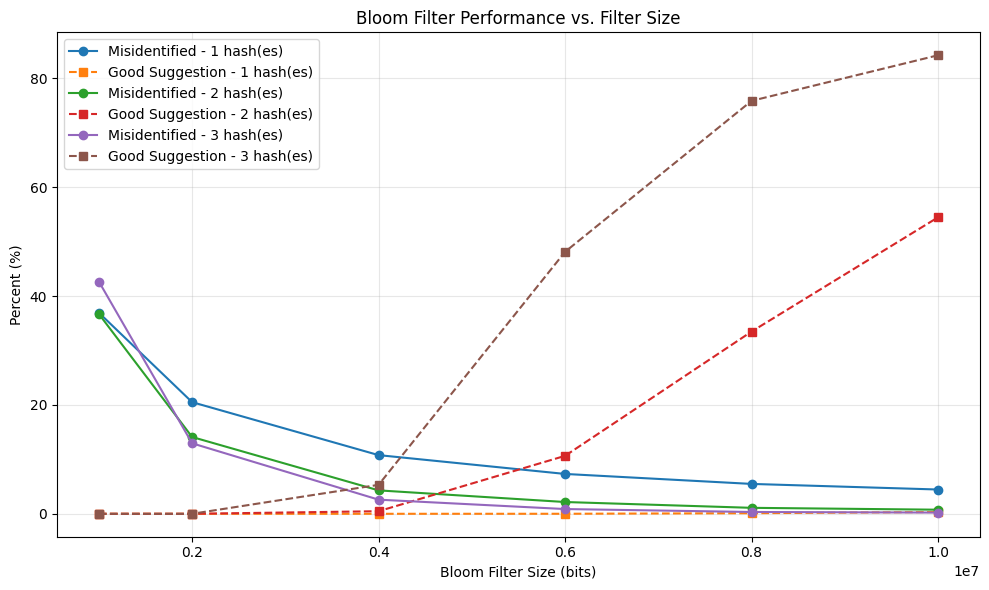

In [15]:
plt.figure(figsize=(10, 6))

for number_of_hashes in [1, 2, 3]:

    # Misidentified Percent: solid lines
    plt.plot(
        filter_sizes,
        misidentified_results[number_of_hashes],
        marker="o",
        linestyle="-",
        label=f"Misidentified - {number_of_hashes} hash(es)"
    )

    # Good Suggestion Percent: dashed lines
    plt.plot(
        filter_sizes,
        good_suggestion_results[number_of_hashes],
        marker="s",
        linestyle="--",
        label=f"Good Suggestion - {number_of_hashes} hash(es)"
    )


plt.xlabel("Bloom Filter Size (bits)")
plt.ylabel("Percent (%)")
plt.title("Bloom Filter Performance vs. Filter Size")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Optional: save the figure
plt.savefig(
    "bloom_filter_evaluation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()